# Initilization Cell

In [1]:
import xarray as xr                                              
import matplotlib.pyplot as plt             
import cartopy.crs as ccrs                  
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import gc
from scipy.interpolate import interp1d
from io import StringIO
import glob
import os
import earthaccess
auth = earthaccess.login(persist=True)
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind, mannwhitneyu, pointbiserialr
import matplotlib.colors as mcolors
from scipy.stats import linregress, spearmanr
bbox = (-118, 32, -117, 33)  # west, south, east, north

# Data loading and formatting
Pretty much the same between XQAA and Physat notebook, matches chl bin sample points to the nearest valid satellite pixels, per date and outputs df wiht spectral values


In [2]:
# defines path to cache folder and csv file
AOP_CLIP_DIR = "granule_cache/aop_clipped"
PICKS_PATH = "chl_transect_picks.csv"

# reads in files and drops rows missing selected values
df = pd.read_csv(PICKS_PATH, parse_dates=["date"])
df = df.dropna(subset=["lat", "lon", "chl"]).reset_index(drop=True)

# nearest pixels to use for calc
N_NEAREST = 10

# convert lat/lon to 3D Cartesian (xyz) coordinates
def latlon_to_xyz(lat, lon):
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    return np.stack([np.cos(lat_r) * np.cos(lon_r),
                      np.cos(lat_r) * np.sin(lon_r),
                      np.sin(lat_r)], axis=-1)

In [3]:
# Reads the already clipped AOP file for selected date
def get_clipped_granule(date_str):
    matches = glob.glob(os.path.join(AOP_CLIP_DIR, f"aop_clipped_{date_str}.nc"))
    if not matches:
        raise ValueError(f"No clipped AOP granule for {date_str} in {AOP_CLIP_DIR}")
    return xr.open_dataset(matches[0], chunks={})  # flat dataset (dims: y, x, wavelength)

records = []
west, south, east, north = bbox

#looks up date in data
for date_str, group_rows in df.groupby(df["date"].dt.strftime("%Y-%m-%d")):
    try: #Fetch that date's satellite granule; skip the date if it fails
        ds = get_clipped_granule(date_str)
    except ValueError as e:
        continue
        
# Pull out the lat/lon grids created in cell above, the wavelength axis, and keep Rrs as an xarray
    lat_grid = ds["latitude"].values
    lon_grid = ds["longitude"].values
    wavelengths = ds["wavelength"].values
    rrs_da = ds["Rrs"]

# creates mask over bbox for land and ice/clouds
    BAD_BITS = (1 << 1) | (1 << 9)  # LAND | CLDICE
    flags_grid = ds["l2_flags"].values.astype(int)
    mask = (
        (lat_grid >= south) & (lat_grid <= north) &
        (lon_grid >= west) & (lon_grid <= east) &
        ((flags_grid & BAD_BITS) == 0) )

    ys, xs = np.where(mask)
   
# converts valid pixels' lat/lon to 3D Cartesian coordinates for distance
    xyz_grid = latlon_to_xyz(lat_grid[ys, xs], lon_grid[ys, xs])  # (M, 3)

# converts  sample points' lat/lon to the same 3D Cartesian system.
    target_xyz = latlon_to_xyz(group_rows["lat"].values, group_rows["lon"].values)  # (n_rows, 3)

# distance from every sample point to every valid pixel
    d = np.linalg.norm(target_xyz[:, None, :] - xyz_grid[None, :, :], axis=2)  # (n_rows, M)
    flat_idx = np.argsort(d, axis=1)[:, :N_NEAREST] # Sorts each row's distances                          # (n_rows, k)
    dist_km = np.take_along_axis(d, flat_idx, axis=1) * 6371.0 # Pulls out the actual distance values at those sorted positions                 # (n_rows, k)

# maps the nearest-neighbor indices
    sel_y = ys[flat_idx]   # (n_rows, k)
    sel_x = xs[flat_idx]   # (n_rows, k)

#  fetches the Rrs spectrum at every selected (y, x) pair
    spectra = rrs_da.isel(
        y=xr.DataArray(sel_y, dims=("pt", "k")),
        x=xr.DataArray(sel_x, dims=("pt", "k")),).values   # (n_rows, k, n_wave)

# marks which (row, rank) pairs have at least one non-NaN wavelength value
    n_wave = spectra.shape[2]
    good = ~np.all(np.isnan(spectra), axis=2)
    row_i, rank_j = np.where(good)
    
# selects metadata for each row
    meta = group_rows.iloc[row_i].reset_index()

#appends the data frame wiht updated vales 
    records.append(pd.DataFrame({
        "row_idx":       np.repeat(meta["index"].values, n_wave),
        "group":         np.repeat(meta["group"].values, n_wave),
        "date":          np.repeat(meta["date"].values, n_wave),
        "level":         np.repeat(meta["level"].values, n_wave),
        "chl":           np.repeat(meta["chl"].values, n_wave),
        "pixel_rank":    np.repeat(rank_j, n_wave),
        "pixel_dist_km": np.repeat(dist_km[row_i, rank_j], n_wave),
        "wavelength":    np.tile(wavelengths, len(row_i)),
        "rrs":           spectra[row_i, rank_j, :].ravel(),}))

# closes and cleans up opened dfs 
    ds.close()
    del lat_grid, lon_grid, rrs_da, ds
    
# consolidates into one long df
rrs_long = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
print(f"Fetched {len(rrs_long)} spectral records across {rrs_long['row_idx'].nunique()} rows")

Fetched 890960 spectral records across 518 rows


In [4]:
# creates a new categorical label in the original picks 
df["chl_bin"] = df["level"] + "_chl"
no_pn_dates = pd.to_datetime(df.loc[df["group"] == "No PS but High CH", "date"].unique()).normalize()

In [5]:
rrs_long

,row_idx,group,date,level,chl,pixel_rank,pixel_dist_km,wavelength,rrs
0,0,No PS but High CH,2024-03-15,mid,1.905828,0,0.731612,346.0,0.003436
1,0,No PS but High CH,2024-03-15,mid,1.905828,0,0.731612,348.0,0.003822
2,0,No PS but High CH,2024-03-15,mid,1.905828,0,0.731612,351.0,0.003906
3,0,No PS but High CH,2024-03-15,mid,1.905828,0,0.731612,353.0,0.003890
4,0,No PS but High CH,2024-03-15,mid,1.905828,0,0.731612,356.0,0.004224
...,...,...,...,...,...,...,...,...,...
890955,521,No PS but High CH,2026-05-30,mid,1.823937,9,3.410225,712.0,0.000184
890956,521,No PS but High CH,2026-05-30,mid,1.823937,9,3.410225,713.0,0.000176
890957,521,No PS but High CH,2026-05-30,mid,1.823937,9,3.410225,714.0,0.000170
890958,521,No PS but High CH,2026-05-30,mid,1.823937,9,3.410225,717.0,0.000124


# Final calculation and df creation

In [6]:

# Takes rrs_long built earlier, makes a copy 
def build_final_df(rl, df):
    rl = rl.copy()
    rl["chl_bin"] = rl["level"] + "_chl"

    ref_long = rl[rl["date"].isin(no_pn_dates)].copy() # filters table down to only rows whose date is in no_pn_dates

    # for each combination of chl_bin, takes the median Rrs value across all the reference pixels/points
    # produces one median reflectance value per wavelength per chl bin 
    median_shape = (ref_long.groupby(["chl_bin", "wavelength"], as_index=False, observed=True)["rrs"]
                .median().rename(columns={"rrs": "rrs_median"}))
    
    # collapse each point's  nearest pixels into a single spectrum
    point_rrs = (rl.groupby(["row_idx", "group", "date", "level", "chl", "wavelength"], as_index=False)
          ["rrs"].median())

    point_rrs = point_rrs.merge(df[["chl_bin"]], left_on="row_idx", right_index=True, how="left") # attach each point's chl_bin
    point_rrs = point_rrs.merge(median_shape, on=["chl_bin", "wavelength"], how="left") # for each point's spectrum, attaches the corresponding baseline

    #actual aRrs computation step
    point_rrs["aRrs"] = point_rrs["rrs"] - point_rrs["rrs_median"]

    return point_rrs.sort_values(["date", "row_idx", "wavelength"]).reset_index(drop=True)


final_df = build_final_df(rrs_long, df)
final_df.to_csv("final_df.csv", index=False)
final_df

,row_idx,group,date,level,chl,wavelength,rrs,chl_bin,rrs_median,aRrs
0,0,No PS but High CH,2024-03-15,mid,1.905828,346.0,0.003959,mid_chl,-0.000097,0.004056
1,0,No PS but High CH,2024-03-15,mid,1.905828,348.0,0.004238,mid_chl,0.000023,0.004215
2,0,No PS but High CH,2024-03-15,mid,1.905828,351.0,0.004428,mid_chl,0.000254,0.004174
3,0,No PS but High CH,2024-03-15,mid,1.905828,353.0,0.004376,mid_chl,0.000289,0.004087
4,0,No PS but High CH,2024-03-15,mid,1.905828,356.0,0.004626,mid_chl,0.000401,0.004225
...,...,...,...,...,...,...,...,...,...,...
89091,521,No PS but High CH,2026-05-30,mid,1.823937,712.0,0.000141,mid_chl,0.000104,0.000037
89092,521,No PS but High CH,2026-05-30,mid,1.823937,713.0,0.000135,mid_chl,0.000102,0.000033
89093,521,No PS but High CH,2026-05-30,mid,1.823937,714.0,0.000123,mid_chl,0.000090,0.000033
89094,521,No PS but High CH,2026-05-30,mid,1.823937,717.0,0.000073,mid_chl,0.000036,0.000037


# Plotting 

Found 53 high-chl Known PS days: ['2024-04-29', '2024-05-07', '2024-05-09', '2024-07-25', '2024-07-28', '2024-07-30', '2024-12-09', '2024-12-16', '2024-12-17', '2024-12-18', '2024-12-19', '2025-01-04', '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-09', '2025-01-10', '2025-01-11', '2025-01-12', '2025-01-13', '2025-01-14', '2025-01-15', '2025-01-17', '2025-01-18', '2025-01-21', '2025-01-27', '2025-01-29', '2025-02-01', '2025-02-19', '2025-02-20', '2025-02-23', '2025-03-18', '2025-03-19', '2025-03-20', '2025-03-21', '2025-03-22', '2025-04-01', '2025-04-03', '2025-04-04', '2025-04-05', '2025-04-20', '2025-04-23', '2025-07-04', '2025-07-05', '2025-07-06', '2026-02-25', '2026-02-26', '2026-02-28', '2026-03-03', '2026-03-08', '2026-04-20', '2026-04-28', '2026-05-01']


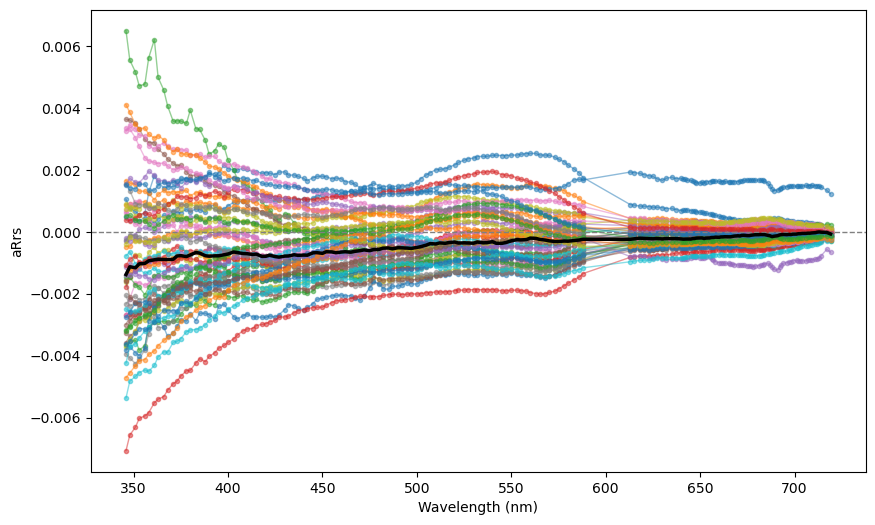

In [14]:
# All PN plotting code

level = "high"

# Filter to level selection of Known PS days
plot_df = final_df[
    (final_df["group"] == "Known PS") &
    (final_df["level"] == level)
].copy()

plot_df["date_str"] = plot_df["date"].dt.strftime("%Y-%m-%d")
dates = sorted(plot_df["date_str"].unique())
print(f"Found {len(dates)} high-chl Known PS days:", dates)

# Median spectrum across the days, per wavelength
median_spectrum = (
    plot_df.groupby("wavelength", as_index=False)["aRrs"]
           .median()
           .sort_values("wavelength"))

fig, ax = plt.subplots(figsize=(10, 6))

# Individual day lines 
for date_str in dates:
    sub = plot_df[plot_df["date_str"] == date_str].sort_values("wavelength")
    ax.plot(sub["wavelength"], sub["aRrs"], marker="o", markersize=3,
             linewidth=1, alpha=0.5, label=date_str)

# Median line 
ax.plot(median_spectrum["wavelength"], median_spectrum["aRrs"],
         color="black", linewidth=2.5, label=f"Median ({len(dates)} days)", zorder=5)

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("aRrs")
plt.show()

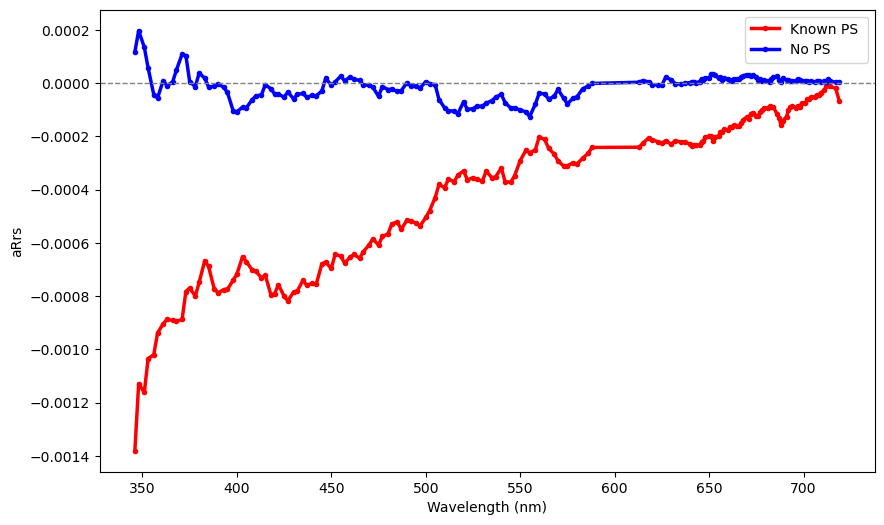

In [7]:

# Filter to high-chl days for both groups
ps_df = final_df[
    (final_df["group"] == "Known PS") &
    (final_df["level"] == "high")].copy()

no_ps_df = final_df[
    (final_df["group"] == "No PS but High CH") &
    (final_df["level"] == "high")].copy()

# Median aRrs spectrum 
ps_median = (
    ps_df.groupby("wavelength", as_index=False)["aRrs"]
         .median()
         .sort_values("wavelength"))

no_ps_median = (
    no_ps_df.groupby("wavelength", as_index=False)["aRrs"]
            .median()
            .sort_values("wavelength"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ps_median["wavelength"], ps_median["aRrs"],
        color="red", linewidth=2.5, marker="o", markersize=3,
        label="Known PS ")

ax.plot(no_ps_median["wavelength"], no_ps_median["aRrs"],
        color="blue", linewidth=2.5, marker="o", markersize=3,
        label="No PS ")

ax.axhline(0, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("aRrs")
ax.legend()
plt.show()

# Subplots 

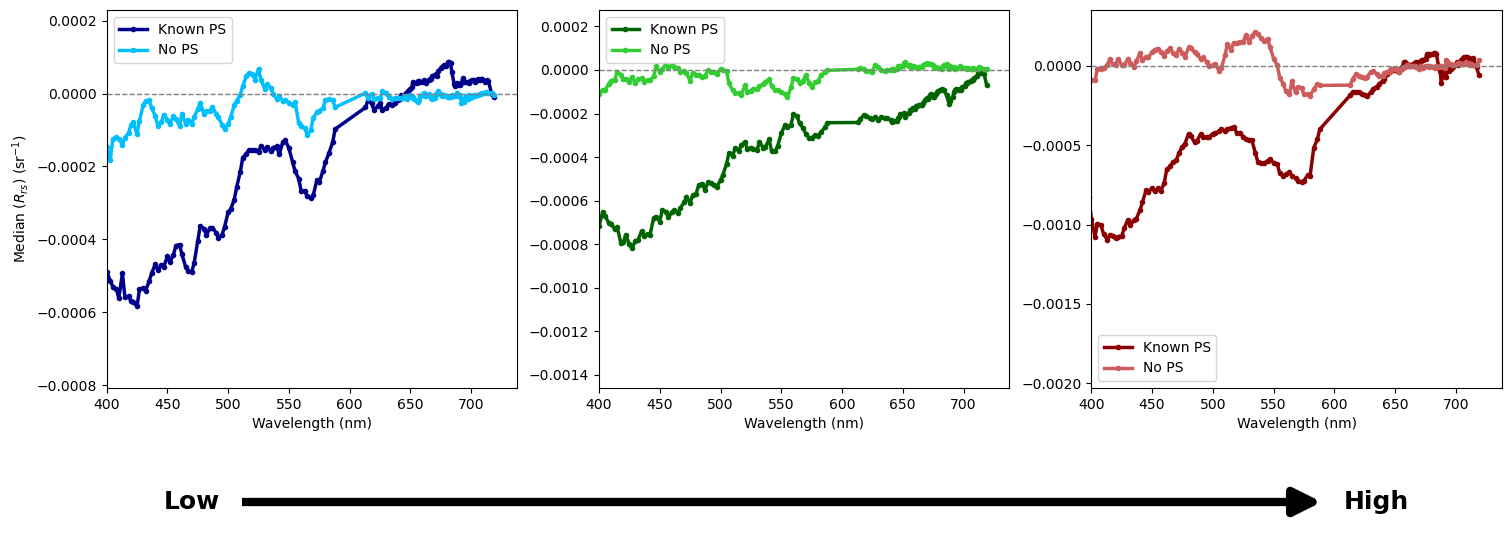

In [8]:
from matplotlib.patches import FancyArrowPatch

levels = ["mid", "high", "very_high"]
level_colors = {
    "mid":       {"Known PS": "darkblue",  "No PS": "deepskyblue"},
    "high":      {"Known PS": "darkgreen", "No PS": "limegreen"},
    "very_high": {"Known PS": "darkred",   "No PS": "indianred"},
}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, level in zip(axes, levels):
    ps_df = final_df[
        (final_df["group"] == "Known PS") &
        (final_df["level"] == level)].copy()
    no_ps_df = final_df[
        (final_df["group"] == "No PS but High CH") &
        (final_df["level"] == level)].copy()
    ps_median = (
        ps_df.groupby("wavelength", as_index=False)["aRrs"]
             .median()
             .sort_values("wavelength"))
    no_ps_median = (
        no_ps_df.groupby("wavelength", as_index=False)["aRrs"]
                .median()
                .sort_values("wavelength"))
    colors = level_colors[level]
    ax.plot(ps_median["wavelength"], ps_median["aRrs"],
            color=colors["Known PS"], linewidth=2.5, marker="o", markersize=3,
            label="Known PS")
    ax.plot(no_ps_median["wavelength"], no_ps_median["aRrs"],
            color=colors["No PS"], linewidth=2.5, marker="o", markersize=3,
            label="No PS")
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.set_xlim(400, )
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()
axes[0].set_ylabel(r"Median ($R_{rs}$) (sr$^{-1}$)")

fig.subplots_adjust(bottom=0.25)

arrow_ax = fig.add_axes([0.2, 0.02, 0.6, 0.08])
arrow_ax.set_xlim(0, 1)
arrow_ax.set_ylim(0, 1)
arrow_ax.axis("off")

arrow = FancyArrowPatch(
    (0, 0.5), (1, 0.5),
    arrowstyle="-|>", mutation_scale=40,
    linewidth=6, color="black",
    shrinkA=0, shrinkB=0,)

arrow_ax.add_patch(arrow)

arrow_ax.text(-0.02, 0.5, "Low", ha="right", va="center", fontsize=18,
              fontweight="bold")
arrow_ax.text(1.02, 0.5, "High", ha="left", va="center", fontsize=18,
              fontweight="bold")

plt.savefig("PHYsat 3 box plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Stats 

Brightness is the average  value across all wavelengths  for each sample pointr epresenting how bright or dim that point's overall spectrum is. R² is the squared point biserial correlation between groups  what proportion of the variation in brightness across all your points is explained by what group

## Brightness Box Plot

/tmp/ipykernel_1665/2889298591.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])


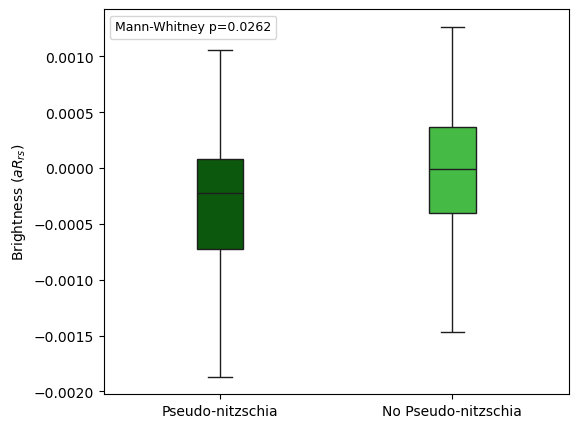

In [15]:
CHL_BIN = "high"  # "low", "mid", "high", "very_high", or None for all bins combined
scoped_df = final_df if CHL_BIN is None else final_df[final_df["level"] == CHL_BIN]
# restrict wavelengths
scoped_df = scoped_df[(scoped_df["wavelength"] >= 400) & (scoped_df["wavelength"] <= 700)]

point_stats_brightness = scoped_df.groupby("row_idx").agg(
    group=("group", "first"),
    brightness=("aRrs", "median"),).reset_index()

ps = point_stats_brightness[point_stats_brightness["group"] == "Known PS"]
no_ps = point_stats_brightness[point_stats_brightness["group"] == "No PS but High CH"]

# Mann-Whitney U
u_stat, u_p = mannwhitneyu(ps["brightness"].dropna(), no_ps["brightness"].dropna())

fig, ax = plt.subplots(figsize=(6, 5))
box_colors = {"Known PS": "darkgreen", "No PS but High CH": "limegreen"}
sns.boxplot(data=point_stats_brightness, x="group", y="brightness", ax=ax,
            order=["Known PS", "No PS but High CH"], showfliers=False, width=0.2,
            hue="group", palette=box_colors, legend=False)
ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])
legend_elements = [
    Line2D([0], [0], color="none", label=f"Mann-Whitney p={u_p:.3g}"),]

ax.legend(handles=legend_elements, loc="upper left", handlelength=0,
          handletextpad=0, frameon=True, fontsize=9)

#ax.set_title(r"Brightness ($aR_{rs}$)")
ax.set_ylabel("Brightness ($aR_{rs}$)")
ax.set_xlabel("")
plt.savefig("Physat BRightness box plot.png", dpi=300, bbox_inches="tight")
plt.show()

## SAM Box plot

/tmp/ipykernel_1665/4091681663.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])


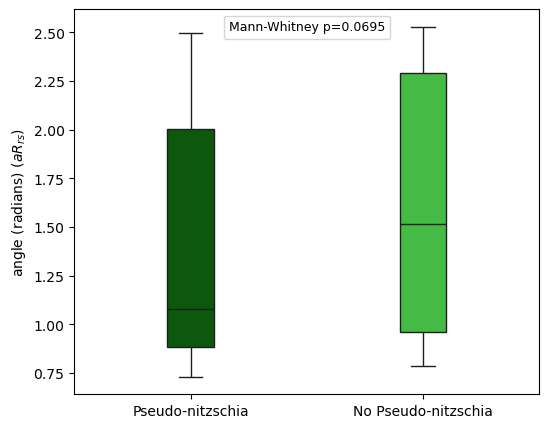

In [10]:
CHL_BIN = "high"  # "low", "mid", "high", "very_high", or None for all bins combined
scoped_df = final_df if CHL_BIN is None else final_df[final_df["level"] == CHL_BIN]
scoped_df = scoped_df[(scoped_df["wavelength"] >= 400) & (scoped_df["wavelength"] <= 700)]

# reference spectrum: median No PS spectrum, per wavelength
reference = (scoped_df[scoped_df["group"] == "No PS but High CH"]
             .groupby("wavelength")["aRrs"].median()
             .sort_index())

wide = scoped_df.pivot_table(index="row_idx", columns="wavelength", values="aRrs")
wide = wide[reference.index]

def spectral_angle(row, ref):
    row = row.values
    valid = ~np.isnan(row)
    if valid.sum() < 2:
        return np.nan
    r, s = ref.values[valid], row[valid]
    cos_theta = np.dot(s, r) / (np.linalg.norm(s) * np.linalg.norm(r))
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.arccos(cos_theta)

sam_vals = wide.apply(lambda row: spectral_angle(row, reference), axis=1).rename("sam")
meta = scoped_df.groupby("row_idx")["group"].first()
point_stats_sam = pd.concat([meta, sam_vals], axis=1).reset_index()

ps = point_stats_sam[point_stats_sam["group"] == "Known PS"]
no_ps = point_stats_sam[point_stats_sam["group"] == "No PS but High CH"]

# Mann-Whitney U
u_stat, u_p = mannwhitneyu(ps["sam"].dropna(), no_ps["sam"].dropna())

fig, ax = plt.subplots(figsize=(6, 5))
box_colors = {"Known PS": "darkgreen", "No PS but High CH": "limegreen"}
sns.boxplot(data=point_stats_sam, x="group", y="sam", ax=ax,
            order=["Known PS", "No PS but High CH"], showfliers=False, width=0.2,
            hue="group", palette=box_colors, legend=False)
ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])

#print(point_stats_sam.groupby("group")["sam"].describe())
legend_elements = [
    Line2D([0], [0], color="none", label=f"Mann-Whitney p={u_p:.3g}"),]

ax.legend(handles=legend_elements, loc="upper center", handlelength=0,
          handletextpad=0, frameon=True, fontsize=9)
#ax.set_title(r"SAM ($aR_{rs}$)")
ax.set_ylabel("angle (radians) ($aR_{rs}$)")
ax.set_xlabel("")
plt.savefig("Physat SAM box plot.png", dpi=300, bbox_inches="tight")
plt.show()

## SAM PN CC vs LR

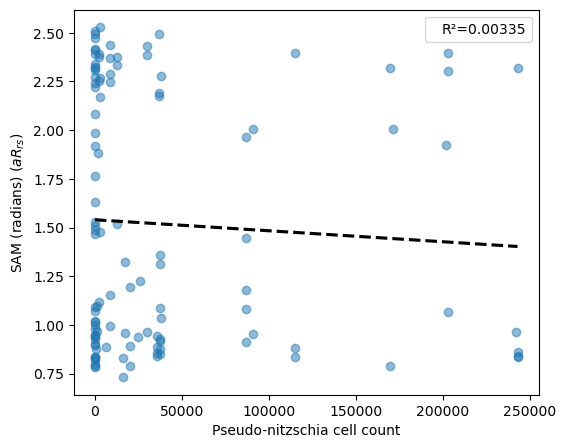

In [11]:
# load and prep count
counts_df = pd.read_csv("chl_transect_picks.csv")
date_counts = counts_df.groupby("date")["count"].first().reset_index()
date_counts["date"] = pd.to_datetime(date_counts["date"])
final_df["date"] = pd.to_datetime(final_df["date"])

#  merge count into point_stats_sam
point_stats = point_stats_sam.merge(
    final_df[["row_idx", "date"]].drop_duplicates(), on="row_idx", how="left"
).merge(date_counts, on="date", how="left")

# SAM vs count
mask = point_stats["count"].notna() & point_stats["sam"].notna()
x = point_stats.loc[mask, "count"]
y = point_stats.loc[mask, "sam"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
rho, sp_p = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(x=x, y=y, ax=ax, scatter_kws={"alpha": 0.5},
    line_kws={"color": "black", "linestyle": "--"},
    ci=None,)
legend_elements = [
    Line2D([0], [0], color="none", label=f"R\u00b2={r_squared:.3g}"),]

ax.legend(handles=legend_elements, loc="upper right", handlelength=0)
ax.set_xlabel("Pseudo-nitzschia cell count")
ax.set_ylabel("SAM (radians) ($aR_{rs}$)")
#ax.set_title("SAM vs PN Cell Count")
plt.savefig("Physat SAM LR plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Brightness vs PN CC LR


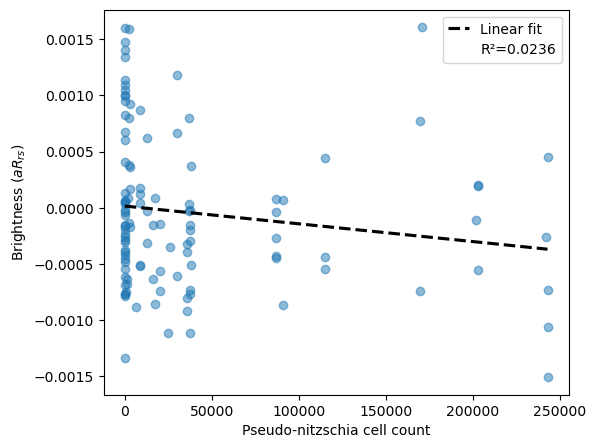

In [12]:
# load and prep count
counts_df = pd.read_csv("chl_transect_picks.csv")
date_counts = counts_df.groupby("date")["count"].first().reset_index()
date_counts["date"] = pd.to_datetime(date_counts["date"])
final_df["date"] = pd.to_datetime(final_df["date"])

# merge count into point_stats_brightness
point_stats = point_stats_brightness.merge(
    final_df[["row_idx", "date"]].drop_duplicates(), on="row_idx", how="left"
).merge(date_counts, on="date", how="left")

# brightness vs count
mask = point_stats["count"].notna() & point_stats["brightness"].notna()
x = point_stats.loc[mask, "count"]
y = point_stats.loc[mask, "brightness"]

slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
rho, sp_p = spearmanr(x, y)

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(
    x=x, y=y, ax=ax,
    scatter_kws={"alpha": 0.5, "label": "Observed points"},
    line_kws={"color": "black", "linestyle": "--", "label": "Linear fit"},
    ci=None,)

# combine the regplot handles with the R² annotation
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="none"))
labels.append(f"R\u00b2={r_squared:.3g}")
ax.legend(handles=handles, labels=labels, loc="upper right", handlelength=1.5)

ax.set_xlabel("Pseudo-nitzschia cell count")
ax.set_ylabel(r"Brightness ($aR_{rs}$)")
plt.savefig("Physat Brightness LR plot.png", dpi=300, bbox_inches="tight")
plt.show()